In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import os.path
from pathlib import Path
import glob
from PIL import Image

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [4]:
import random
from zipfile import ZipFile

In [6]:
# Reproducible results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset locations
PROJECT_DIR = Path.cwd()
ZIP_PATH = PROJECT_DIR / "archive(1).zip"
DATA_ROOT = PROJECT_DIR / "data"
DATA_DIR = DATA_ROOT / "Data"

# Extract only if it has not been extracted before
if not DATA_DIR.exists():
    DATA_ROOT.mkdir(exist_ok=True)

    with ZipFile(ZIP_PATH, "r") as zip_file:
        zip_file.extractall(DATA_ROOT)

    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted — no extraction needed.")

# Verify the two class folders
for class_folder in DATA_DIR.iterdir():
    if class_folder.is_dir():
        image_count = len(list(class_folder.rglob("*.jpg")))
        print(f"{class_folder.name}: {image_count} images")
        print(f"total images: {len(list(DATA_DIR.rglob('*.jpg')))}")

Using device: cpu
Dataset already extracted — no extraction needed.
Hemorrhagic: 2690 images
total images: 6795
NORMAL: 4105 images
total images: 6795


In [7]:
for class_name in ["Hemorrhagic", "NORMAL"]:
    class_dir = DATA_DIR / class_name

    scan_folders = [
        folder for folder in class_dir.rglob("*")
        if folder.is_dir() and any(folder.glob("*.jpg"))
    ]

    print(f"\n{class_name}")
    print(f"Folders containing CT slices: {len(scan_folders)}")

    for folder in scan_folders[:5]:
        slices = list(folder.glob("*.jpg"))
        print(f"  {folder.relative_to(DATA_DIR)} → {len(slices)} slices")


Hemorrhagic
Folders containing CT slices: 18
  Hemorrhagic\KANAMA\11[11] → 204 slices
  Hemorrhagic\KANAMA\12[12] → 203 slices
  Hemorrhagic\KANAMA\13[13] → 221 slices
  Hemorrhagic\KANAMA\14[14] → 130 slices
  Hemorrhagic\KANAMA\15[15] → 196 slices

NORMAL
Folders containing CT slices: 27
  NORMAL\N10[N10] → 122 slices
  NORMAL\N11[N11] → 128 slices
  NORMAL\N12[N12] → 130 slices
  NORMAL\N13[N13] → 128 slices
  NORMAL\N14[N14] → 46 slices


In [8]:
scan_records = []

for class_name, label in [("Hemorrhagic", 1), ("NORMAL", 0)]:
    class_dir = DATA_DIR / class_name

    for folder in class_dir.rglob("*"):
        if folder.is_dir() and any(folder.glob("*.jpg")):
            scan_records.append(
                {
                    "scan_id": str(folder.relative_to(DATA_DIR)),
                    "class_name": class_name,
                    "label": label,
                    "slice_count": len(list(folder.glob("*.jpg"))),
                }
            )

scans_df = pd.DataFrame(scan_records)
scans_df.head()

,scan_id,class_name,label,slice_count
0,Hemorrhagic\KANAMA\11[11],Hemorrhagic,1,204
1,Hemorrhagic\KANAMA\12[12],Hemorrhagic,1,203
2,Hemorrhagic\KANAMA\13[13],Hemorrhagic,1,221
3,Hemorrhagic\KANAMA\14[14],Hemorrhagic,1,130
4,Hemorrhagic\KANAMA\15[15],Hemorrhagic,1,196


In [10]:
scan_summary = (
    scans_df.groupby("class_name")
    .agg(
        scans=("scan_id", "count"),
        total_slices=("slice_count", "sum"),
        average_slices=("slice_count", "mean"),
        min_slices=("slice_count", "min"),
        max_slices=("slice_count", "max"),
    )
    .round(1)
)

scan_summary

,scans,total_slices,average_slices,min_slices,max_slices
class_name,,,,,
Hemorrhagic,18,2690,149.4,23,232
NORMAL,27,4105,152.0,46,360


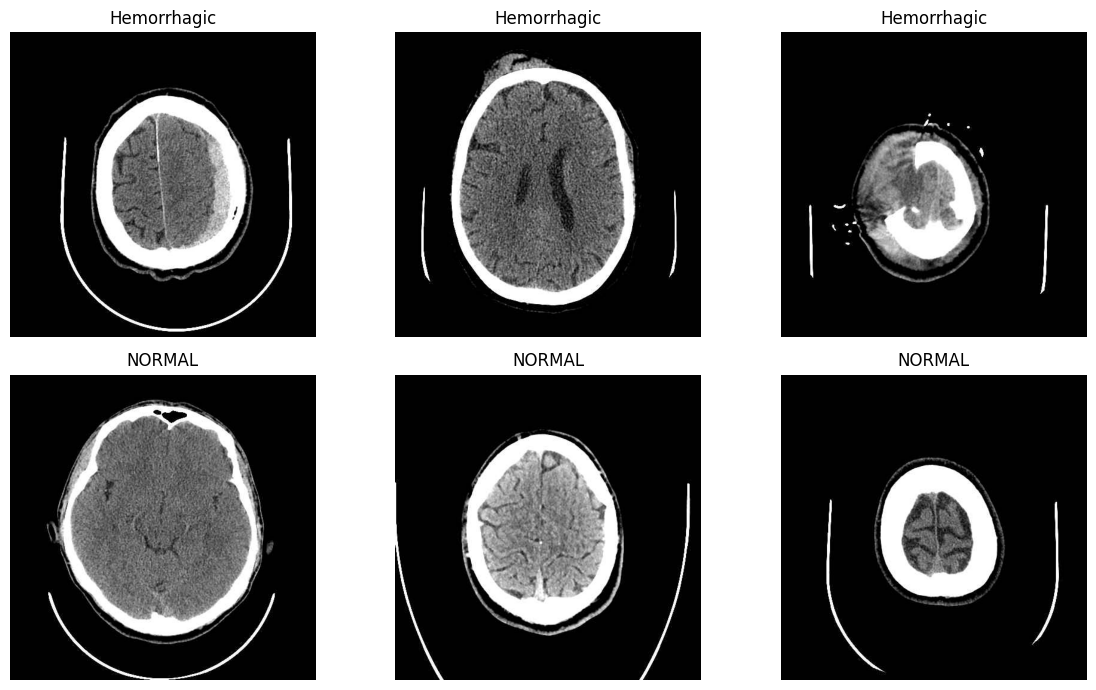

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for row, class_name in enumerate(["Hemorrhagic", "NORMAL"]):
    image_paths = list((DATA_DIR / class_name).rglob("*.jpg"))
    samples = random.sample(image_paths, 3)

    for col, image_path in enumerate(samples):
        image = Image.open(image_path).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [12]:
from collections import Counter

image_sizes = []
image_modes = []
unreadable_images = []

for image_path in DATA_DIR.rglob("*.jpg"):
    try:
        with Image.open(image_path) as image:
            image.load()
            image_sizes.append(image.size)
            image_modes.append(image.mode)
    except Exception:
        unreadable_images.append(image_path)

print(f"Readable images: {len(image_sizes)}")
print(f"Unreadable images: {len(unreadable_images)}")
print("\nMost common image sizes:")
print(Counter(image_sizes).most_common(5))
print("\nImage color modes:")
print(Counter(image_modes))

Readable images: 6795
Unreadable images: 0

Most common image sizes:
[((512, 512), 6772), ((317, 376), 1), ((483, 482), 1), ((444, 496), 1), ((463, 480), 1)]

Image color modes:
Counter({'RGB': 6795})


In [13]:
nonstandard_images = []

for image_path in DATA_DIR.rglob("*.jpg"):
    with Image.open(image_path) as image:
        if image.size != (512, 512):
            nonstandard_images.append(
                {
                    "image_path": str(image_path.relative_to(DATA_DIR)),
                    "image_size": image.size,
                }
            )

nonstandard_df = pd.DataFrame(nonstandard_images)

print(f"Non-512×512 images: {len(nonstandard_df)}")
nonstandard_df.head(10)

Non-512×512 images: 23


,image_path,image_size
0,Hemorrhagic\KANAMA\19[19]\1.JPG,"(317, 376)"
1,Hemorrhagic\KANAMA\19[19]\10.JPG,"(483, 482)"
2,Hemorrhagic\KANAMA\19[19]\11.JPG,"(444, 496)"
3,Hemorrhagic\KANAMA\19[19]\12.JPG,"(463, 480)"
4,Hemorrhagic\KANAMA\19[19]\13.JPG,"(515, 498)"
5,Hemorrhagic\KANAMA\19[19]\14.JPG,"(479, 509)"
6,Hemorrhagic\KANAMA\19[19]\15.JPG,"(472, 509)"
7,Hemorrhagic\KANAMA\19[19]\16.JPG,"(514, 491)"
8,Hemorrhagic\KANAMA\19[19]\17.JPG,"(495, 499)"
9,Hemorrhagic\KANAMA\19[19]\18.JPG,"(499, 494)"


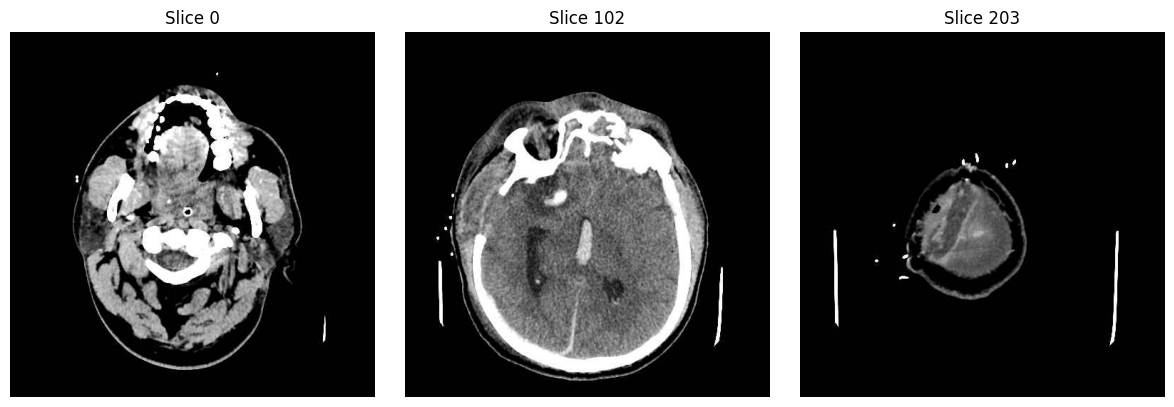

In [14]:
import re

scan_folder = DATA_DIR / "Hemorrhagic" / "KANAMA" / "11[11]"

slices = sorted(
    scan_folder.glob("*.jpg"),
    key=lambda path: int(re.findall(r"\d+", path.stem)[-1])
)

selected_indices = [0, len(slices) // 2, len(slices) - 1]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for axis, index in zip(axes, selected_indices):
    image = Image.open(slices[index]).convert("RGB")
    axis.imshow(image)
    axis.set_title(f"Slice {index}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [15]:
import hashlib

hash_to_paths = {}

for image_path in DATA_DIR.rglob("*"):
    if image_path.suffix.lower() == ".jpg":
        image_hash = hashlib.md5(image_path.read_bytes()).hexdigest()
        hash_to_paths.setdefault(image_hash, []).append(image_path)

duplicate_groups = [
    paths for paths in hash_to_paths.values()
    if len(paths) > 1
]

print(f"Exact duplicate groups: {len(duplicate_groups)}")
print(f"Images involved in duplicate groups: {sum(len(group) for group in duplicate_groups)}")

Exact duplicate groups: 136
Images involved in duplicate groups: 272


In [16]:
duplicate_records = []

for paths in duplicate_groups:
    classes = {path.relative_to(DATA_DIR).parts[0] for path in paths}
    scans = {str(path.parent.relative_to(DATA_DIR)) for path in paths}

    duplicate_records.append(
        {
            "images_in_group": len(paths),
            "different_scans": len(scans) > 1,
            "different_classes": len(classes) > 1,
            "example_path": str(paths[0].relative_to(DATA_DIR)),
        }
    )

duplicates_df = pd.DataFrame(duplicate_records)

print("Duplicate groups across different scans:", duplicates_df["different_scans"].sum())
print("Duplicate groups across different classes:", duplicates_df["different_classes"].sum())

duplicates_df.head(10)

Duplicate groups across different scans: 135
Duplicate groups across different classes: 0


,images_in_group,different_scans,different_classes,example_path
0,2,True,False,NORMAL\N27[N27]\N27_0_100.jpg
1,2,True,False,NORMAL\N27[N27]\N27_0_101.jpg
2,2,True,False,NORMAL\N27[N27]\N27_0_102.jpg
3,2,True,False,NORMAL\N27[N27]\N27_0_103.jpg
4,2,True,False,NORMAL\N27[N27]\N27_0_104.jpg
5,2,True,False,NORMAL\N27[N27]\N27_0_105.jpg
6,2,True,False,NORMAL\N27[N27]\N27_0_106.jpg
7,2,True,False,NORMAL\N27[N27]\N27_0_107.jpg
8,2,True,False,NORMAL\N27[N27]\N27_0_108.jpg
9,2,True,False,NORMAL\N27[N27]\N27_0_109.jpg


In [17]:
from itertools import combinations

scan_pair_counts = Counter()

for paths in duplicate_groups:
    scans = sorted({str(path.parent.relative_to(DATA_DIR)) for path in paths})

    for scan_a, scan_b in combinations(scans, 2):
        scan_pair_counts[(scan_a, scan_b)] += 1

duplicate_pairs_df = pd.DataFrame(
    [
        {
            "scan_a": pair[0],
            "scan_b": pair[1],
            "shared_duplicate_images": count,
        }
        for pair, count in scan_pair_counts.items()
    ]
).sort_values("shared_duplicate_images", ascending=False)

duplicate_pairs_df.head(10)

,scan_a,scan_b,shared_duplicate_images
0,NORMAL\N27[N27],NORMAL\N6[N6],135


In [18]:
scan_a = DATA_DIR / "NORMAL" / "N6[N6]"
scan_b = DATA_DIR / "NORMAL" / "N27[N27]"

hashes_a = {
    hashlib.md5(path.read_bytes()).hexdigest()
    for path in scan_a.glob("*.jpg")
}

hashes_b = {
    hashlib.md5(path.read_bytes()).hexdigest()
    for path in scan_b.glob("*.jpg")
}

shared_hashes = hashes_a & hashes_b

print(f"N6 slices: {len(hashes_a)}")
print(f"N27 slices: {len(hashes_b)}")
print(f"Shared exact slices: {len(shared_hashes)}")

N6 slices: 135
N27 slices: 136
Shared exact slices: 135


In [19]:
excluded_scan_id = r"NORMAL\N27[N27]"

scans_df_clean = (
    scans_df[scans_df["scan_id"] != excluded_scan_id]
    .copy()
    .reset_index(drop=True)
)

print(f"Scans before exclusion: {len(scans_df)}")
print(f"Scans after exclusion: {len(scans_df_clean)}")

scans_df_clean["class_name"].value_counts()

Scans before exclusion: 45
Scans after exclusion: 44


class_name
NORMAL         26
Hemorrhagic    18
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

train_val_scans, test_scans = train_test_split(
    scans_df_clean,
    test_size=0.20,
    stratify=scans_df_clean["label"],
    random_state=SEED,
)

train_scans, val_scans = train_test_split(
    train_val_scans,
    test_size=0.1875,
    stratify=train_val_scans["label"],
    random_state=SEED,
)

In [21]:
split_summary = pd.concat(
    [
        train_scans.assign(split="train"),
        val_scans.assign(split="validation"),
        test_scans.assign(split="test"),
    ]
)

split_summary = (
    split_summary.groupby(["split", "class_name"])
    .agg(
        scans=("scan_id", "count"),
        slices=("slice_count", "sum"),
    )
    .reset_index()
)

split_summary

,split,class_name,scans,slices
0,test,Hemorrhagic,4,532
1,test,NORMAL,5,997
2,train,Hemorrhagic,11,1759
3,train,NORMAL,17,2444
4,validation,Hemorrhagic,3,399
5,validation,NORMAL,4,528


In [22]:
def build_image_dataframe(scan_dataframe):
    records = []

    for _, scan in scan_dataframe.iterrows():
        scan_folder = DATA_DIR / scan["scan_id"]

        for image_path in scan_folder.glob("*.jpg"):
            records.append(
                {
                    "image_path": image_path,
                    "scan_id": scan["scan_id"],
                    "class_name": scan["class_name"],
                    "label": scan["label"],
                }
            )

    return pd.DataFrame(records)


train_images = build_image_dataframe(train_scans)
val_images = build_image_dataframe(val_scans)
test_images = build_image_dataframe(test_scans)

In [23]:
for split_name, images_df in [
    ("Train", train_images),
    ("Validation", val_images),
    ("Test", test_images),
]:
    print(f"\n{split_name}: {len(images_df)} images")
    print(images_df["class_name"].value_counts())


Train: 4203 images
class_name
NORMAL         2444
Hemorrhagic    1759
Name: count, dtype: int64

Validation: 927 images
class_name
NORMAL         528
Hemorrhagic    399
Name: count, dtype: int64

Test: 1529 images
class_name
NORMAL         997
Hemorrhagic    532
Name: count, dtype: int64


In [24]:
IMAGE_SIZE = 224

resnet_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)

In [25]:
sample_path = train_images.iloc[0]["image_path"]

with Image.open(sample_path) as image:
    sample_tensor = resnet_transform(image.convert("RGB"))

print("Tensor shape:", sample_tensor.shape)
print("Data type:", sample_tensor.dtype)
print("Minimum value:", sample_tensor.min().item())
print("Maximum value:", sample_tensor.max().item())

Tensor shape: torch.Size([3, 224, 224])
Data type: torch.float32
Minimum value: -2.1179039478302
Maximum value: 2.640000104904175


In [26]:
class CTImageDataset(Dataset):
    def __init__(self, images_dataframe, transform=None):
        self.images_dataframe = images_dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.images_dataframe)

    def __getitem__(self, index):
        row = self.images_dataframe.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")

            if self.transform:
                image = self.transform(image)

        label = torch.tensor(row["label"], dtype=torch.long)

        return image, label

In [27]:
train_dataset = CTImageDataset(train_images, transform=resnet_transform)
val_dataset = CTImageDataset(val_images, transform=resnet_transform)
test_dataset = CTImageDataset(test_images, transform=resnet_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Validation dataset: {len(val_dataset)} images")
print(f"Test dataset: {len(test_dataset)} images")

Train dataset: 4203 images
Validation dataset: 927 images
Test dataset: 1529 images


In [28]:
image_tensor, label = train_dataset[0]

print("Image shape:", image_tensor.shape)
print("Label:", label.item())
print("Class:", "Hemorrhagic" if label.item() == 1 else "NORMAL")

Image shape: torch.Size([3, 224, 224])
Label: 0
Class: NORMAL


In [29]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [30]:
batch_images, batch_labels = next(iter(train_loader))

print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)
print("Labels in this batch:", torch.bincount(batch_labels))

Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16])
Labels in this batch: tensor([10,  6])


In [31]:
class_names = ["NORMAL", "Hemorrhagic"]

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=len(class_names),
)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\prana/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:24<00:00, 1.89MB/s]

Linear(in_features=512, out_features=2, bias=True)


In [32]:
class_counts = train_images["label"].value_counts().sort_index()

class_weights = len(train_images) / (
    len(class_counts) * class_counts.values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device,
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)

Class weights: tensor([0.8599, 1.1947])


In [33]:
for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.fc.parameters():
    parameter.requires_grad = True

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

In [34]:
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")

Trainable parameters: 1,026
Total parameters: 11,177,538


In [35]:
EPOCHS = 10

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = MODEL_DIR / "resnet18_head_only_best.pt"

best_val_auc = -float("inf")
history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": [],
}

In [36]:
def evaluate(model, data_loader):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probabilities = torch.softmax(outputs, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    average_loss = total_loss / len(data_loader.dataset)
    auc = roc_auc_score(all_labels, all_probabilities)

    return average_loss, auc

In [37]:
def train_one_epoch(model, data_loader):
    model.eval()
    model.fc.train()

    total_loss = 0.0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(data_loader.dataset)

In [38]:
initial_val_loss, initial_val_auc = evaluate(model, val_loader)

print(f"Initial validation loss: {initial_val_loss:.4f}")
print(f"Initial validation ROC-AUC: {initial_val_auc:.4f}")

Initial validation loss: 0.8658
Initial validation ROC-AUC: 0.3861


In [39]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_auc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f} | "
        f"Validation AUC: {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "class_names": class_names,
                "image_size": IMAGE_SIZE,
                "best_val_auc": best_val_auc,
                "history": history,
            },
            CHECKPOINT_PATH,
        )

        print(f"  Best model saved to: {CHECKPOINT_PATH}")

Epoch 1/10 | Train loss: 0.6231 | Validation loss: 0.6953 | Validation AUC: 0.6631
  Best model saved to: e:\vscode\Vision model practice\models\resnet18_head_only_best.pt
Epoch 2/10 | Train loss: 0.5045 | Validation loss: 0.6058 | Validation AUC: 0.7243
  Best model saved to: e:\vscode\Vision model practice\models\resnet18_head_only_best.pt
Epoch 3/10 | Train loss: 0.4503 | Validation loss: 0.5956 | Validation AUC: 0.7468
  Best model saved to: e:\vscode\Vision model practice\models\resnet18_head_only_best.pt
Epoch 4/10 | Train loss: 0.4013 | Validation loss: 0.5952 | Validation AUC: 0.7519
  Best model saved to: e:\vscode\Vision model practice\models\resnet18_head_only_best.pt
Epoch 5/10 | Train loss: 0.3741 | Validation loss: 0.5921 | Validation AUC: 0.7463
Epoch 6/10 | Train loss: 0.3546 | Validation loss: 0.6092 | Validation AUC: 0.7375
Epoch 7/10 | Train loss: 0.3266 | Validation loss: 0.6048 | Validation AUC: 0.7402
Epoch 8/10 | Train loss: 0.3201 | Validation loss: 0.6200 | Val

In [40]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded best model from epoch: {checkpoint['epoch']}")
print(f"Best validation AUC: {checkpoint['best_val_auc']:.4f}")

Loaded best model from epoch: 4
Best validation AUC: 0.7519


In [41]:
test_loss, test_auc = evaluate(model, test_loader)

print(f"Test loss: {test_loss:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

Test loss: 0.5758
Test ROC-AUC: 0.7508


In [42]:
test_labels = []
test_probabilities = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)[:, 1]

        test_labels.extend(labels.numpy())
        test_probabilities.extend(probabilities.cpu().numpy())

test_labels = np.array(test_labels)
test_probabilities = np.array(test_probabilities)
test_predictions = (test_probabilities >= 0.5).astype(int)

In [43]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)

tn, fp, fn, tp = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1],
).ravel()

test_metrics = pd.Series(
    {
        "Loss": test_loss,
        "Accuracy": accuracy_score(test_labels, test_predictions),
        "Balanced accuracy": balanced_accuracy_score(
            test_labels, test_predictions
        ),
        "Precision": precision_score(test_labels, test_predictions),
        "Recall / Sensitivity": recall_score(test_labels, test_predictions),
        "Specificity": tn / (tn + fp),
        "F1 score": f1_score(test_labels, test_predictions),
        "ROC-AUC": roc_auc_score(test_labels, test_probabilities),
        "PR-AUC": average_precision_score(
            test_labels, test_probabilities
        ),
    }
)

test_metrics.round(4)

Loss                    0.5758
Accuracy                0.7050
Balanced accuracy       0.6905
Precision               0.5672
Recall / Sensitivity    0.6429
Specificity             0.7382
F1 score                0.6026
ROC-AUC                 0.7508
PR-AUC                  0.7051
dtype: float64

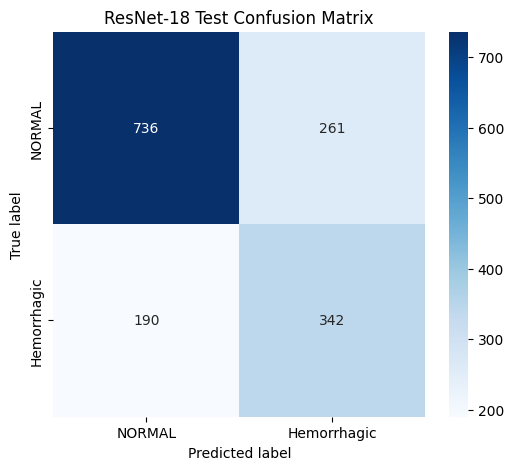

In [44]:
confusion_matrix_values = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1],
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("ResNet-18 Test Confusion Matrix")
plt.show()

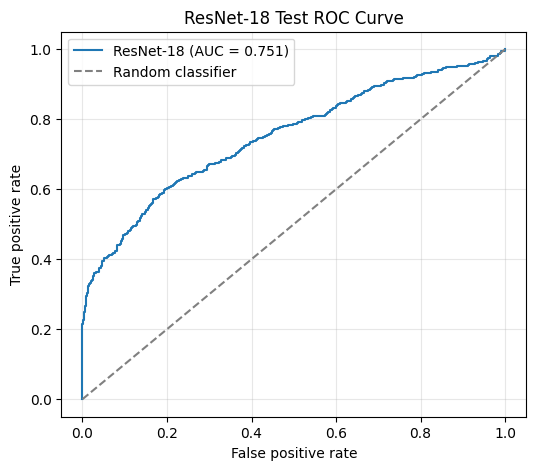

In [45]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, _ = roc_curve(
    test_labels,
    test_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ResNet-18 (AUC = {test_auc:.3f})",
)

plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ResNet-18 Test ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

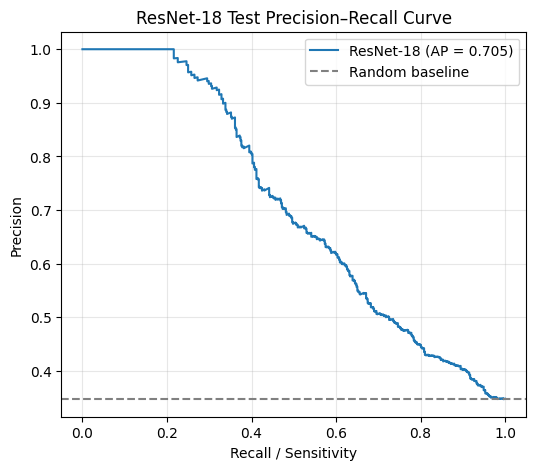

In [46]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    test_labels,
    test_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"ResNet-18 (AP = {test_metrics['PR-AUC']:.3f})",
)

plt.axhline(
    test_labels.mean(),
    linestyle="--",
    color="gray",
    label="Random baseline",
)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("ResNet-18 Test Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

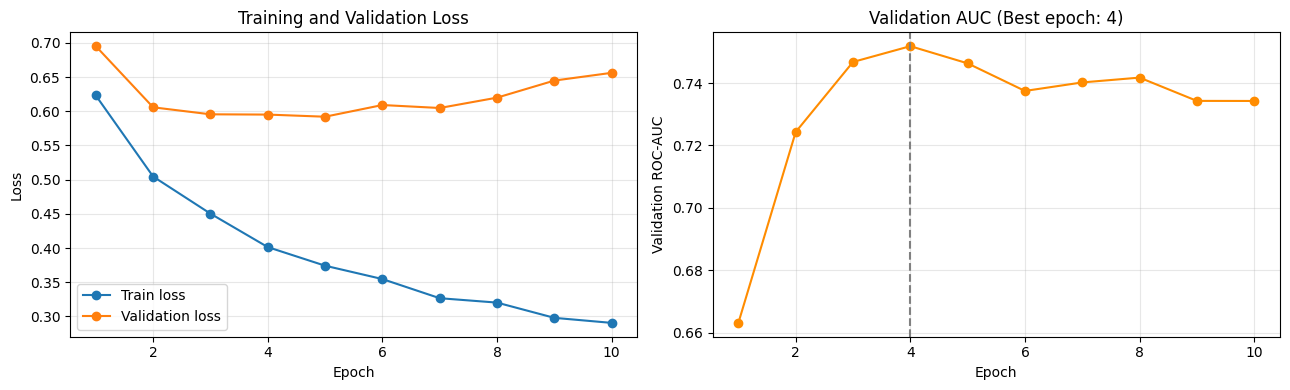

In [47]:
epochs = range(1, len(history["train_loss"]) + 1)
best_epoch = np.argmax(history["val_auc"]) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train loss")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["val_auc"], marker="o", color="darkorange")
axes[1].axvline(best_epoch, linestyle="--", color="gray")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation ROC-AUC")
axes[1].set_title(f"Validation AUC (Best epoch: {best_epoch})")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()